In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import ast
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from shapely.geometry import LineString, Point
from tqdm import tqdm
from itertools import combinations
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor, early_stopping
import shap
from scipy.stats import zscore
from scipy.spatial import cKDTree
import os
import fiona
import random
from geopy.distance import geodesic

/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.UInt64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)


In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")
meteo_doubs = pd.read_csv("../data/meteo/meteostat_doubs.csv")
doubs_voisins = pd.read_csv("../data/data_train_test/doubs_tous_voisins.csv")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [4]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [5]:
doubs_data = doubs_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(doubs_data)
doubs_data.dropna(axis=1, thresh=threshold, inplace=True)

doubs_data.dropna(inplace=True)

In [6]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y
compagnies = compagnies.to_crs(epsg=4326)

caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnies'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnies'].isna().sum()
print(f"Nombre de casernes sans id_compagnies : {none_count}")

print(caserne[['compagnie', 'id_compagnies']].head())

if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

Nombre de casernes sans id_compagnies : 0
         compagnie  id_compagnies
0         Besançon            1.0
1  Baume-les-Dames            2.0
2      Montbéliard            6.0
3       Pontarlier            4.0
4      Montbéliard            6.0


In [7]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
compagnies = gpd.GeoDataFrame(compagnies, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
compagnies = compagnies.to_crs(epsg=4326)

doubs_data['id_compagnies'] = None

for idx, hexagone in doubs_data.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if len(intersecting_companies) == 1:
        doubs_data.at[idx, 'id_compagnies'] = intersecting_companies.iloc[0]['id']
    elif len(intersecting_companies) > 1:
        max_area = 0
        best_company_id = None
        for _, company in intersecting_companies.iterrows():
            intersection = hexagone['geometry'].intersection(company['geometry'])
            area = intersection.area
            if area > max_area:
                max_area = area
                best_company_id = company['id']

        doubs_data.at[idx, 'id_compagnies'] = best_company_id

print(doubs_data[['hex_id', 'id_compagnies']].head())

            hex_id id_compagnies
0  871f820aaffffff           4.0
1  871f82d61ffffff          12.0
2  871f82d61ffffff          12.0
3  871f82d4dffffff           1.0
4  871f82700ffffff           5.0


In [8]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
caserne = caserne.to_crs(epsg=4326)

doubs_data['id_caserne'] = None
doubs_data['distance'] = None

for idx, hexagone in doubs_data.iterrows():
    casernes_same_company = caserne[caserne['id_compagnies'] == hexagone['id_compagnies']]

    if casernes_same_company.empty:
        continue

    distances = casernes_same_company.geometry.distance(hexagone['geometry'])

    nearest_caserne_idx = distances.idxmin()
    nearest_caserne = casernes_same_company.loc[nearest_caserne_idx]

    doubs_data.at[idx, 'id_caserne'] = nearest_caserne['id_pg']
    doubs_data.at[idx, 'distance'] = distances.min()

print(doubs_data[['hex_id', 'id_compagnies', 'id_caserne', 'distance']].head())

Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



            hex_id id_compagnies id_caserne  distance
0  871f820aaffffff           4.0     840709       0.0
1  871f82d61ffffff          12.0     840704  0.005327
2  871f82d61ffffff          12.0     840704  0.005327
3  871f82d4dffffff           1.0     840698  0.039716
4  871f82700ffffff           5.0     840701  0.010387


In [9]:
doubs_data.head()

,hex_id,raison_sortie,date_debut,date_fin,label,year,date,departement,duree_minutes,geometry,...,crops,shrub,flooded,built,bare,snow,sinister,id_compagnies,id_caserne,distance
0,871f820aaffffff,NATURELS,2014-10-02 14:08:53,2014-10-02 19:54:25,1.0,2014.0,2014-10-02,departement-25-doubs,345.533333,"POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...",...,0.478770,1.713494,0.062996,3.112007,0.604763,0.0,1.0,4.0,840709,0.0
1,871f82d61ffffff,NATURELS,2014-10-03 19:33:59,2014-10-03 19:55:31,1.0,2014.0,2014-10-03,departement-25-doubs,21.533333,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,1.453672,17.671597,0.037922,6.345595,0.000000,0.0,2.0,12.0,840704,0.005327
2,871f82d61ffffff,NATURELS,2014-10-04 19:24:49,2014-10-04 19:59:02,1.0,2014.0,2014-10-04,departement-25-doubs,34.216667,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,1.453672,17.671597,0.037922,6.345595,0.000000,0.0,2.0,12.0,840704,0.005327
3,871f82d4dffffff,NATURELS,2014-10-04 20:10:43,2014-10-04 20:42:34,1.0,2014.0,2014-10-04,departement-25-doubs,31.850000,"POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...",...,0.063147,1.780753,0.025259,10.204597,0.000000,0.0,6.0,1.0,840698,0.039716
4,871f82700ffffff,NATURELS,2014-10-05 12:57:52,2014-10-05 13:24:24,1.0,2014.0,2014-10-05,departement-25-doubs,26.533333,"POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...",...,0.478288,0.138452,0.088106,11.164254,0.000000,0.0,2.0,5.0,840701,0.010387


In [10]:
doubs_data['date'] = pd.to_datetime(doubs_data['date'])

def get_saison(month):
    if month in [12, 1, 2]:
        return 'Hiver'
    elif month in [3, 4, 5]:
        return 'Printemps'
    elif month in [6, 7, 8]:
        return 'Été'
    else:
        return 'Automne'

doubs_data['saison'] = doubs_data['date'].dt.month.apply(get_saison)

doubs_data['saison_annee'] = doubs_data['saison'] + ' ' + doubs_data['date'].dt.year.astype(str)

print(doubs_data[['date', 'saison', 'saison_annee']].head())

        date   saison  saison_annee
0 2014-10-02  Automne  Automne 2014
1 2014-10-03  Automne  Automne 2014
2 2014-10-04  Automne  Automne 2014
3 2014-10-04  Automne  Automne 2014
4 2014-10-05  Automne  Automne 2014


In [11]:
cols_to_drop = [
    'raison_sortie', 'label', 'departement', 'duree',
    'index', 'longitude', 'latitude', 'sinister', 'id_caserne', 'date_debut', 'date_fin', 'year', 'scale0', 'hour', 'month', 'weekday', 'distance', 'saison'
]

doubs_data = doubs_data.drop(columns=[col for col in cols_to_drop if col in doubs_data.columns])

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -193.308183   365.771043  35.301036  49.568009  0.030354   
1   2.1  -207.285164   379.748023  37.570279  50.756412  0.041264   
2   2.2  -221.262145   393.725004  37.570279  50.756412  0.041264   
3   2.3  -235.239125   407.701985  37.456715  51.824335  0.063704   
4   2.4  -249.216106   421.678965  38.777120  55.530498  0.042433   
5   2.5  -263.193087   435.655946  37.191344  54.357449  0.082462   
6   2.6  -277.170067   449.632927  37.416691  53.991449 -0.016037   
7   2.7  -291.147048   463.609907  36.014943  52.960120  0.022409   
8   2.8  -305.124029   477.586888  36.578454  55.067346  0.026893   
9   2.9  -319.101009   491.563869  36.578454  55.067346  0.026893   
10  3.0  -333.077990   505.540849  37.234171  57.746589  0.023126   
11  3.1  -347.054971   519.517830  36.426815  56.146294  0.076518   
12  3.2  -361.031951   533.494811  37.683943  57.799374  0.021339   
13  3.3  -375.008932   547.471791 

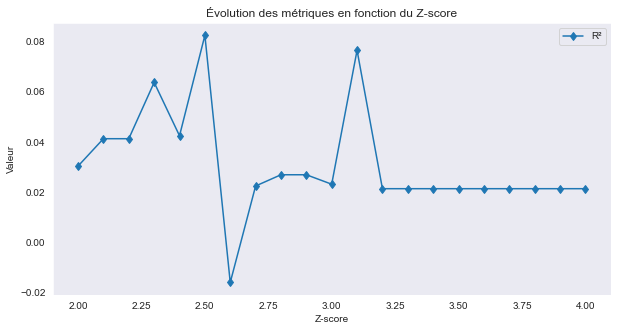

In [12]:
df = doubs_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'id_compagnies', 'saison_annee']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'id_compagnies', 'saison_annee']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

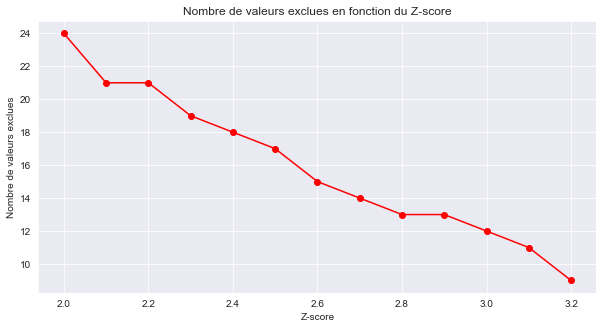

In [13]:
df = doubs_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

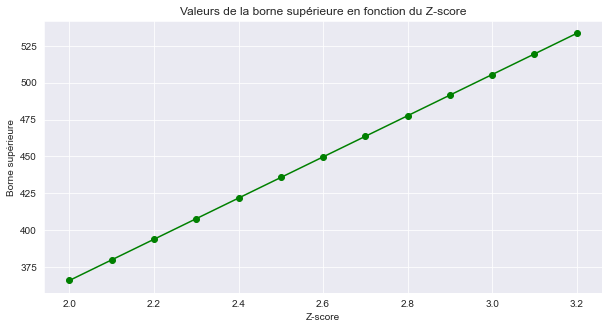

In [14]:
df = doubs_data.copy()

upper_bounds = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df['z_score'] = np.abs(zscore(df['duree_minutes']))

    upper_bound = df['duree_minutes'].mean() + z * df['duree_minutes'].std()

    upper_bounds.append(upper_bound)

plt.figure(figsize=(10, 5))
plt.plot(z_values, upper_bounds, label="Borne supérieure", marker='o', color='green')
plt.xlabel("Z-score")
plt.ylabel("Borne supérieure")
plt.title("Valeurs de la borne supérieure en fonction du Z-score")
plt.grid(True)
plt.show()

In [15]:
doubs_data['z_score'] = np.abs(zscore(doubs_data['duree_minutes']))

doubs_data_filtered = doubs_data[doubs_data['z_score'] <= 2.9].drop(columns=['z_score'])

values_removed = len(doubs_data) - len(doubs_data_filtered)
print(f"Nombre de valeurs supprimées : {values_removed}")
print(f"Pourcentage des données supprimées : {values_removed / len(doubs_data) * 100:.2f}%")

Nombre de valeurs supprimées : 13
Pourcentage des données supprimées : 0.49%


In [16]:
doubs_data_filtered['date'] = pd.to_datetime(doubs_data_filtered['date'])
meteo_doubs['creneau'] = pd.to_datetime(meteo_doubs['creneau'])

meteo_doubs['geometry'] = [Point(xy) for xy in zip(meteo_doubs['longitude'], meteo_doubs['latitude'])]
meteo_gdf = gpd.GeoDataFrame(meteo_doubs, geometry='geometry', crs="EPSG:4326")

doubs_data_filtered = doubs_data_filtered.to_crs("EPSG:32631")
meteo_gdf = meteo_gdf.to_crs("EPSG:32631")

def trouver_meteo_proche(row, meteo_gdf):
    meteo_jour = meteo_gdf[meteo_gdf['creneau'] == row['date']]
    if meteo_jour.empty:
        return pd.Series([np.nan] * len(meteo_gdf.columns), index=meteo_gdf.columns)

    centroid = row.geometry.centroid
    centroid_x, centroid_y = centroid.x, centroid.y

    tree = cKDTree(np.array(list(zip(meteo_jour.geometry.x, meteo_jour.geometry.y))))
    dist, idx = tree.query([centroid_x, centroid_y], k=1)

    return meteo_jour.iloc[idx]

meteo_associee = doubs_data_filtered.apply(lambda row: trouver_meteo_proche(row, meteo_gdf), axis=1)

meteo_associee = meteo_associee.rename(columns={'geometry': 'geometry_meteo'})

doubs_data_filtered = pd.concat([doubs_data_filtered.reset_index(drop=True), meteo_associee.reset_index(drop=True)], axis=1)

doubs_data_filtered = doubs_data_filtered.loc[:, ~doubs_data_filtered.columns.duplicated()]

In [17]:
colonnes_a_supprimer = ['geometry_meteo', 'year', 'longitude', 'latitude', 'index', 'creneau']
doubs_data_filtered = doubs_data_filtered.drop(columns=colonnes_a_supprimer)

In [18]:
doubs_data_filtered = doubs_data_filtered.dropna()

In [19]:
cols_a_conserver = ['hex_id', 'geometry', 'centroid', 'id_compagnies', 'saison_annee']

doubs_data_filtered = doubs_data_filtered.drop(columns=['date'])

doubs_data_moy = doubs_data_filtered.groupby(['hex_id', 'saison_annee'], as_index=False).mean(numeric_only=True)

doubs_data_conserve = doubs_data_filtered[cols_a_conserver].drop_duplicates(subset=['hex_id', 'saison_annee'])

doubs_data_final = pd.merge(doubs_data_moy, doubs_data_conserve, on=['hex_id', 'saison_annee'], how='left')

print(doubs_data_final.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
1  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   
2  871f80492ffffff  Printemps 2023      72.083333      6.350198     47.477082   
3  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   
4  871f80492ffffff        Été 2019     168.250000      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...        bui        fwi  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  35.098101  20.429792   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...   9.748193   4.066704   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  30.969181  11.517529   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  30.499293  11.928195   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  78.161184  21.688291   

   daily_severity_rating  

In [20]:
stats_compagnies = (
    doubs_data_final.groupby("id_compagnies")["duree_minutes"]
    .agg(
        moyenne="mean",
        médiane="median",
        minimum="min",
        maximum="max",
        écart_type="std",
        Q1=lambda x: np.percentile(x, 25),
        Q3=lambda x: np.percentile(x, 75),
    )
    .reset_index()
)

In [21]:
doubs_data_final = doubs_data_final.merge(stats_compagnies, on="id_compagnies", how="left")

In [22]:
doubs_data_final.head()

,hex_id,saison_annee,duree_minutes,centroid_lon,centroid_lat,NDVI,NDMI,NDBI,NDSI,NDWI,...,geometry,centroid,id_compagnies,moyenne,médiane,minimum,maximum,écart_type,Q1,Q3
0,871f80492ffffff,Printemps 2019,163.133333,6.350198,47.477082,0.720443,0.145452,-0.145452,-0.59362,-0.672639,...,"POLYGON ((751133.744 5264017.878, 751333.360 5...",POINT (6.35020 47.47708),2.0,85.609959,72.083333,2.85,276.766667,47.482618,49.779167,107.208333
1,871f80492ffffff,Printemps 2022,61.850000,6.350198,47.477082,0.720443,0.145452,-0.145452,-0.59362,-0.672639,...,"POLYGON ((751133.744 5264017.878, 751333.360 5...",POINT (6.35020 47.47708),2.0,85.609959,72.083333,2.85,276.766667,47.482618,49.779167,107.208333
2,871f80492ffffff,Printemps 2023,72.083333,6.350198,47.477082,0.720443,0.145452,-0.145452,-0.59362,-0.672639,...,"POLYGON ((751133.744 5264017.878, 751333.360 5...",POINT (6.35020 47.47708),2.0,85.609959,72.083333,2.85,276.766667,47.482618,49.779167,107.208333
3,871f80492ffffff,Été 2017,197.783333,6.350198,47.477082,0.720443,0.145452,-0.145452,-0.59362,-0.672639,...,"POLYGON ((751133.744 5264017.878, 751333.360 5...",POINT (6.35020 47.47708),2.0,85.609959,72.083333,2.85,276.766667,47.482618,49.779167,107.208333
4,871f80492ffffff,Été 2019,168.250000,6.350198,47.477082,0.720443,0.145452,-0.145452,-0.59362,-0.672639,...,"POLYGON ((751133.744 5264017.878, 751333.360 5...",POINT (6.35020 47.47708),2.0,85.609959,72.083333,2.85,276.766667,47.482618,49.779167,107.208333


In [23]:
ordre_saisons = {'Hiver': 1, 'Printemps': 2, 'Été': 3, 'Automne': 4}

doubs_data_final[['Saison', 'Annee']] = doubs_data_final['saison_annee'].str.split(' ', expand=True)
doubs_data_final['Annee'] = doubs_data_final['Annee'].astype(int)
doubs_data_final['Saison_ordre'] = doubs_data_final['Saison'].map(ordre_saisons)

doubs_data_final = doubs_data_final.sort_values(by=['hex_id', 'Annee', 'Saison_ordre'])

doubs_data_final['moyenne_duree_hex_id'] = (
    doubs_data_final.groupby('hex_id')['duree_minutes']
    .expanding()
    .mean()
    .shift()  # Décaler pour exclure la ligne courante
    .reset_index(level=0, drop=True)
)

doubs_data_final['moyenne_duree_hex_id'].fillna(0, inplace=True)

doubs_data_final.drop(columns=['Saison', 'Annee', 'Saison_ordre'], inplace=True)

In [24]:
test_size = 0.2
random_state = 42
hex_ids = doubs_data_final["hex_id"].unique()
splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(splitter.split(hex_ids, groups=hex_ids))
train_hex = hex_ids[train_idx]
test_hex = hex_ids[test_idx]
doubs_train = doubs_data_final[doubs_data_final["hex_id"].isin(train_hex)]
doubs_test = doubs_data_final[doubs_data_final["hex_id"].isin(test_hex)]
print(f"Taille du train : {doubs_train.shape[0]} lignes")
print(f"Taille du test : {doubs_test.shape[0]} lignes")

Taille du train : 1380 lignes
Taille du test : 359 lignes


In [25]:
common_hex = set(doubs_train["hex_id"]).intersection(set(doubs_test["hex_id"]))
if common_hex:
    print(f"Problème : {len(common_hex)} hex_id sont présents dans les deux datasets.")
else:
    print("Vérification réussie : Aucun hex_id en commun entre train et test.")

Vérification réussie : Aucun hex_id en commun entre train et test.


In [26]:
doubs_train = doubs_train.merge(doubs_voisins[['hex_id', 'hex_voisins']], on='hex_id', how='left')

doubs_test = doubs_test.merge(doubs_voisins[['hex_id', 'hex_voisins']], on='hex_id', how='left')

In [27]:
doubs_train['hex_voisins'] = doubs_train['hex_voisins'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
doubs_test['hex_voisins'] = doubs_test['hex_voisins'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

print(doubs_train['hex_voisins'].head())
print(doubs_test['hex_voisins'].head())

0    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
1    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
2    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
3    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
4    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
Name: hex_voisins, dtype: object
0    [871f8049effffff, 871f8049cffffff, 871f80493ff...
1    [871f804d2ffffff, 871f804d1ffffff, 871f804deff...
2    [871f804d8ffffff, 871f804ceffffff, 871f82b60ff...
3    [871f804d8ffffff, 871f804d1ffffff, 871f82b2dff...
4    [871f8079affffff, 871f806b4ffffff, 871f806b5ff...
Name: hex_voisins, dtype: object


In [28]:
def calculer_statistiques(row, train_data):
    hex_cible = row['hex_id']
    saison_actuelle = row['saison_annee']

    hex_voisins = row['hex_voisins']

    hex_ids_a_prendre = [hex_cible] + hex_voisins
    data_filtree = train_data[train_data['hex_id'].isin(hex_ids_a_prendre)]

    data_filtree = data_filtree[data_filtree['saison_annee'] < saison_actuelle]

    if data_filtree.empty:
        return pd.Series([np.nan] * 7,
                         index=['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
                                'duree_min', 'duree_max', 'duree_q1', 'duree_q3'])

    duree_moyenne = data_filtree['duree_minutes'].mean()
    duree_mediane = data_filtree['duree_minutes'].median()
    duree_ecart_type = data_filtree['duree_minutes'].std()
    duree_min = data_filtree['duree_minutes'].min()
    duree_max = data_filtree['duree_minutes'].max()
    duree_q1 = data_filtree['duree_minutes'].quantile(0.25)
    duree_q3 = data_filtree['duree_minutes'].quantile(0.75)

    return pd.Series([duree_moyenne, duree_mediane, duree_ecart_type,
                      duree_min, duree_max, duree_q1, duree_q3],
                     index=['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
                            'duree_min', 'duree_max', 'duree_q1', 'duree_q3'])

doubs_train[['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
             'duree_min', 'duree_max', 'duree_q1', 'duree_q3']] = doubs_train.apply(
    lambda row: calculer_statistiques(row, doubs_data_final), axis=1)

doubs_test[['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
            'duree_min', 'duree_max', 'duree_q1', 'duree_q3']] = doubs_test.apply(
    lambda row: calculer_statistiques(row, doubs_data_final), axis=1)

print(doubs_train.head())
print(doubs_test.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   
1  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
2  871f80492ffffff        Été 2019     168.250000      6.350198     47.477082   
3  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   
4  871f80492ffffff  Printemps 2023      72.083333      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...          Q3  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   

   moyenne_duree_hex_id                                        hex_voisins  \
0       

In [29]:
colonnes_statistiques = ['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
                         'duree_min', 'duree_max', 'duree_q1', 'duree_q3']

doubs_train[colonnes_statistiques] = doubs_train[colonnes_statistiques].fillna(0)
doubs_test[colonnes_statistiques] = doubs_test[colonnes_statistiques].fillna(0)

print(doubs_train.head())
print(doubs_test.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   
1  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
2  871f80492ffffff        Été 2019     168.250000      6.350198     47.477082   
3  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   
4  871f80492ffffff  Printemps 2023      72.083333      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...          Q3  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   

   moyenne_duree_hex_id                                        hex_voisins  \
0       

In [30]:
features = [col for col in doubs_train.columns if col not in ['duree_minutes', 'hex_id', 'geometry', 'centroid', 'saison_annee', 'hex_voisins', 'id_compagnies']]

X_train = doubs_train[features]
y_train = doubs_train['duree_minutes']

X_test = doubs_test[features]
y_test = doubs_test['duree_minutes']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE du modèle : {mae:.4f}")
print(f"MSE du modèle : {mse:.4f}")
print(f"RMSE du modèle : {rmse:.2f}")
print(f"R² du modèle : {r2:.4f}")

MAE du modèle : 36.3816
MSE du modèle : 2549.6491
RMSE du modèle : 50.49
R² du modèle : 0.0778


In [31]:
"""param_grid = {
    'n_estimators': [50, 100, 200],  # Nombre d'arbres
    'max_depth': [None, 10, 20, 30],  # Profondeur des arbres
    'min_samples_split': [2, 5, 10],  # Minimum de samples pour diviser un noeud
    'min_samples_leaf': [1, 2, 4],    # Minimum de samples pour un noeud terminal
    'max_features': ['auto', 'sqrt', 'log2']  # Nombre de features pour chaque split
}

rf_model = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=5, scoring='neg_mean_squared_error',
                           n_jobs=-1, verbose=2)

grid_search.fit(X_train_scaled, y_train)

print("Meilleurs hyperparamètres :", grid_search.best_params_)
print("Meilleur score (neg_mean_squared_error) :", grid_search.best_score_)

best_rf_model = grid_search.best_estimator_

y_pred = best_rf_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE du modèle : {mae:.4f}")
print(f"MSE du modèle : {mse:.4f}")
print(f"RMSE du modèle : {rmse:.2f}")
print(f"R² du modèle : {r2:.4f}")"""

'param_grid = {\n    \'n_estimators\': [50, 100, 200],  # Nombre d\'arbres\n    \'max_depth\': [None, 10, 20, 30],  # Profondeur des arbres\n    \'min_samples_split\': [2, 5, 10],  # Minimum de samples pour diviser un noeud\n    \'min_samples_leaf\': [1, 2, 4],    # Minimum de samples pour un noeud terminal\n    \'max_features\': [\'auto\', \'sqrt\', \'log2\']  # Nombre de features pour chaque split\n}\n\nrf_model = RandomForestRegressor(random_state=42)\n\ngrid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,\n                           cv=5, scoring=\'neg_mean_squared_error\',\n                           n_jobs=-1, verbose=2)\n\ngrid_search.fit(X_train_scaled, y_train)\n\nprint("Meilleurs hyperparamètres :", grid_search.best_params_)\nprint("Meilleur score (neg_mean_squared_error) :", grid_search.best_score_)\n\nbest_rf_model = grid_search.best_estimator_\n\ny_pred = best_rf_model.predict(X_test_scaled)\n\nmae = mean_absolute_error(y_test, y_pred)\nmse = mean_squared_

In [32]:
"""Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Meilleurs hyperparamètres : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Meilleur score (neg_mean_squared_error) : -2432.703252921102
MAE du modèle : 34.0358
MSE du modèle : 2391.1361
RMSE du modèle : 48.90
R² du modèle : 0.1351"""

"Fitting 5 folds for each of 324 candidates, totalling 1620 fits\nMeilleurs hyperparamètres : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}\nMeilleur score (neg_mean_squared_error) : -2432.703252921102\nMAE du modèle : 34.0358\nMSE du modèle : 2391.1361\nRMSE du modèle : 48.90\nR² du modèle : 0.1351"

In [33]:
doubs_train['nombre_voisins'] = doubs_train['hex_voisins'].apply(lambda x: len(x) if isinstance(x, list) else 0)

doubs_test['nombre_voisins'] = doubs_test['hex_voisins'].apply(lambda x: len(x) if isinstance(x, list) else 0)

voisins_train = doubs_train['nombre_voisins'].value_counts().sort_index()
voisins_test = doubs_test['nombre_voisins'].value_counts().sort_index()

print("Nombre de voisins dans doubs_train:")
print(voisins_train)

print("\nNombre de voisins dans doubs_test:")
print(voisins_test)

Nombre de voisins dans doubs_train:
0       3
1       3
2       1
3       6
4      21
5      26
6    1320
Name: nombre_voisins, dtype: int64

Nombre de voisins dans doubs_test:
3      4
4     11
5      6
6    338
Name: nombre_voisins, dtype: int64


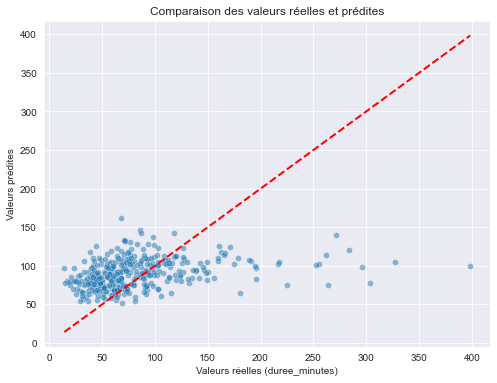

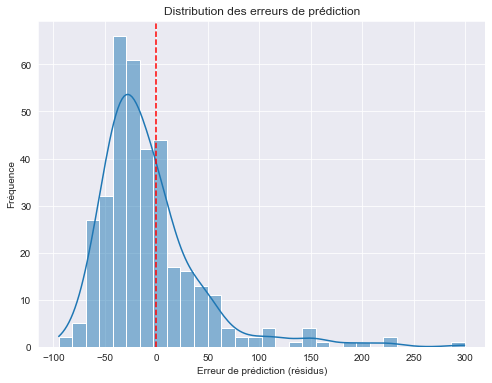

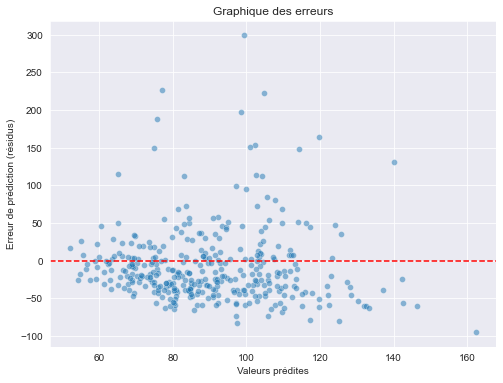

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel("Valeurs réelles (duree_minutes)")
plt.ylabel("Valeurs prédites")
plt.title("Comparaison des valeurs réelles et prédites")
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Erreur de prédiction (résidus)")
plt.ylabel("Fréquence")
plt.title("Distribution des erreurs de prédiction")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Erreur de prédiction (résidus)")
plt.title("Graphique des erreurs")
plt.show()

In [35]:
models = {
    "Régression Linéaire": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

results = {}
X_train, X_test = doubs_train.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'saison_annee', 'hex_voisins', 'id_compagnies']), doubs_test.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'saison_annee', 'hex_voisins', 'id_compagnies'])
y_train, y_test = doubs_train['duree_minutes'], doubs_test['duree_minutes']

for name, model in models.items():
    print(f"Entraînement du modèle : {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"RMSE": rmse, "MAE": mae, "R²": r2}

results_df = pd.DataFrame(results).T
print("\nComparaison des modèles :")
print(results_df.sort_values(by="R²", ascending=False))

Entraînement du modèle : Régression Linéaire
Entraînement du modèle : Random Forest
Entraînement du modèle : Gradient Boosting
Entraînement du modèle : XGBoost
Entraînement du modèle : SVR
Entraînement du modèle : KNN

Comparaison des modèles :
                          RMSE        MAE        R²
Random Forest        50.522548  36.142223  0.076748
Régression Linéaire  50.799105  35.518373  0.066613
Gradient Boosting    50.909634  35.628316  0.062547
XGBoost              51.484277  38.078327  0.041264
SVR                  53.709738  33.714252 -0.043412
KNN                  56.602193  39.133582 -0.158821


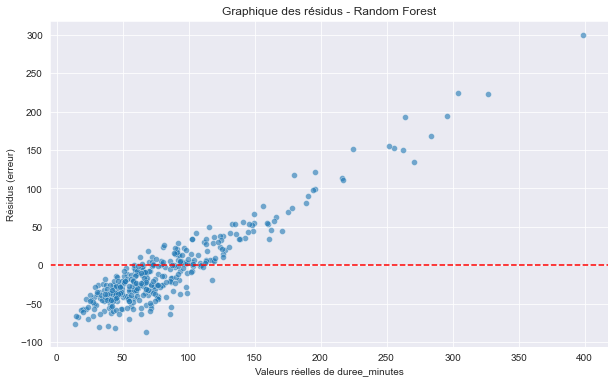

In [36]:
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Valeurs réelles de duree_minutes")
plt.ylabel("Résidus (erreur)")
plt.title("Graphique des résidus - Random Forest")
plt.show()

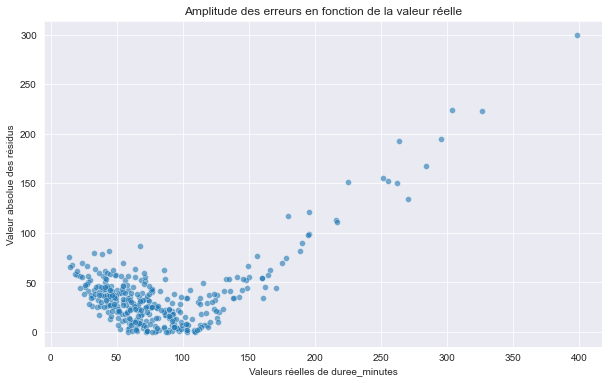

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=np.abs(residuals), alpha=0.6)
plt.xlabel("Valeurs réelles de duree_minutes")
plt.ylabel("Valeur absolue des résidus")
plt.title("Amplitude des erreurs en fonction de la valeur réelle")
plt.show()

In [38]:
doubs_train["duree_minutes_log"] = np.log1p(doubs_train["duree_minutes"])
doubs_test["duree_minutes_log"] = np.log1p(doubs_test["duree_minutes"])

X_train_log, X_test_log = doubs_train.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'saison_annee', 'hex_voisins', 'id_compagnies', 'duree_minutes_log']), doubs_test.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'saison_annee', 'hex_voisins', 'id_compagnies', 'duree_minutes_log'])
y_train_log, y_test_log = doubs_train['duree_minutes_log'], doubs_test['duree_minutes_log']

best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train_log, y_train_log)

y_pred_log = best_model.predict(X_test_log)

y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test_log)

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
mae = mean_absolute_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)

print(f"Performances après transformation log :")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

Performances après transformation log :
RMSE : 50.00
MAE  : 32.46
R²   : 0.0958


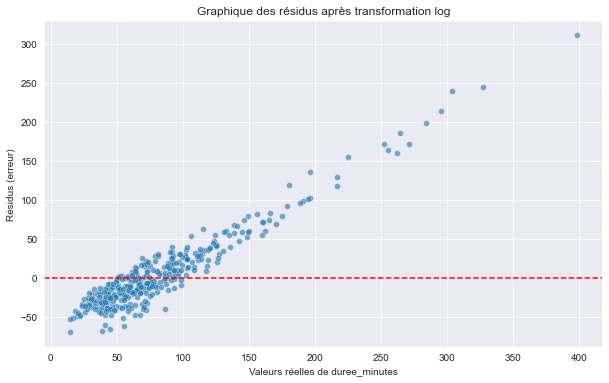

In [39]:
residuals = y_test_orig - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_orig, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Valeurs réelles de duree_minutes")
plt.ylabel("Résidus (erreur)")
plt.title("Graphique des résidus après transformation log")
plt.show()

In [40]:
param_grid = {
    'n_estimators': [100, 300, 500, 800],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

rf_search = RandomizedSearchCV(
    rf, param_distributions=param_grid, n_iter=20, cv=3, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1
)
rf_search.fit(X_train_log, y_train_log)

print("Meilleurs paramètres :", rf_search.best_params_)

best_rf = rf_search.best_estimator_
y_pred_log = best_rf.predict(X_test)
y_pred = np.expm1(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
mae = mean_absolute_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)

print(f"Performances après optimisation RF :")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

Meilleurs paramètres : {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}
Performances après optimisation RF :
RMSE : 49.26
MAE  : 31.79
R²   : 0.1224


In [41]:
import re

def clean_column_name(name):
    return re.sub(r'[^a-zA-Z0-9_]', '_', name)

X_train_log.columns = [clean_column_name(col) for col in X_train_log.columns]
X_test_log.columns = [clean_column_name(col) for col in X_test_log.columns]

print("Colonnes après nettoyage :", X_train_log.columns.tolist())

Colonnes après nettoyage : ['centroid_lon', 'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet', 'Ch_taignier', 'Ch_nes_d_cidus', 'Conif_res', 'Douglas', 'Feuillus', 'H_tre', 'Mixte', 'M_l_ze', 'NC', 'NR', 'Peuplier', 'Pin_autre', 'Pin_laricio__pin_noir', 'Pin_maritime', 'Pin_sylvestre', 'Pins_m_lang_s', 'Robinier', 'Sapin___pic_a', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'temp', 'dwpt', 'rhum', 'prcp', 'wdir', 'wspd', 'pres', 'prec24h', 'snow24h', 'prec24h12', 'snow24h12', 'temp16', 'dwpt16', 'rhum16', 'prcp16', 'wdir16', 'wspd16', 'prec24h16', 'snow24h16', 'temp12', 'dwpt12', 'rhum12', 'prcp12', 'wdir12', 'wspd12', 'temp15h', 'rhum15h', 'temp12h', 'rhum12h', 'temp24max', 'prec24veille', 'sum_rain_last_7_days', 'sum_snow_last_7_days', 'sum_consecutive_rainfall', 'dc', 'days_since_rain', 'ffmc', 'dm

In [42]:
lgb_model = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=20, random_state=42)

lgb_model.fit(X_train_log, y_train_log)

y_pred_log = lgb_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
mae = mean_absolute_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)

print(f"Performances LightGBM :")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002613 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15741
[LightGBM] [Info] Number of data points in the train set: 1380, number of used features: 99
[LightGBM] [Info] Start training from score 4.271250
Performances LightGBM :
RMSE : 50.80
MAE  : 34.39
R²   : 0.0665


In [43]:
def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300, step=10),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'random_state': 42
    }

    model = LGBMRegressor(**params)

    model.fit(
        X_train_log, y_train_log,
        eval_set=[(X_test_log, y_test_log)],
        eval_metric='rmse',
        callbacks=[early_stopping(50)]
    )

    # Prédictions
    y_pred_log = model.predict(X_test_log)
    y_pred = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

best_params = study.best_params
print("Meilleurs hyperparamètres LightGBM :", best_params)

best_model = LGBMRegressor(**best_params)
best_model.fit(X_train_log, y_train_log)

y_pred_log = best_model.predict(X_test_log)
y_pred = np.expm1(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
mae = mean_absolute_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)

print(f"\nPerformances optimisées LightGBM :")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

[I 2025-03-13 13:57:04,899] A new study created in memory with name: no-name-f80e731a-867a-4ddd-b0ac-9cc53519bf88


[LightGBM] [Warning] lambda_l1 is set=0.001568503190116001, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.001568503190116001
[LightGBM] [Warning] lambda_l2 is set=0.06974473180463592, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.06974473180463592
[LightGBM] [Warning] lambda_l1 is set=0.001568503190116001, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.001568503190116001
[LightGBM] [Warning] lambda_l2 is set=0.06974473180463592, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.06974473180463592
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002554 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15741
[LightGBM] [Info] Number of data points in the train set: 1380, number of used features: 99
[LightGBM] [Warning] lambda_l1 is set=0.001568503190116001, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.001568503190116001
[LightGBM] [Warning] lambda_

[I 2025-03-13 13:57:05,134] Trial 0 finished with value: 49.69513641154874 and parameters: {'n_estimators': 100, 'learning_rate': 0.1456081227676306, 'max_depth': 3, 'num_leaves': 210, 'min_child_samples': 24, 'colsample_bytree': 0.799877579624001, 'subsample': 0.5409432843602329, 'lambda_l1': 0.001568503190116001, 'lambda_l2': 0.06974473180463592}. Best is trial 0 with value: 49.69513641154874.


[LightGBM] [Warning] lambda_l1 is set=1.2650161351559427e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2650161351559427e-08
[LightGBM] [Warning] lambda_l2 is set=7.48400855148059e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=7.48400855148059e-06
[LightGBM] [Warning] lambda_l1 is set=1.2650161351559427e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2650161351559427e-08
[LightGBM] [Warning] lambda_l2 is set=7.48400855148059e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=7.48400855148059e-06
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002081 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15741
[LightGBM] [Info] Number of data points in the train set: 1380, number of used features: 99
[LightGBM] [Warning] lambda_l1 is set=1.2650161351559427e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2650161351559427e-08
[LightGBM] [

[I 2025-03-13 13:57:05,503] Trial 1 finished with value: 49.597208076893516 and parameters: {'n_estimators': 650, 'learning_rate': 0.056873429793651294, 'max_depth': 13, 'num_leaves': 180, 'min_child_samples': 51, 'colsample_bytree': 0.5652447990249418, 'subsample': 0.5441761182244504, 'lambda_l1': 1.2650161351559427e-08, 'lambda_l2': 7.48400855148059e-06}. Best is trial 1 with value: 49.597208076893516.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[245]	valid_0's rmse: 0.49601
[LightGBM] [Warning] lambda_l1 is set=3.1592180026932075, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.1592180026932075
[LightGBM] [Warning] lambda_l2 is set=0.004428588498000375, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.004428588498000375
[LightGBM] [Warning] lambda_l1 is set=2.9208701225105607, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.9208701225105607
[LightGBM] [Warning] lambda_l2 is set=0.0089354802080977, reg_lambda=0.0 will be 

[I 2025-03-13 13:57:50,619] Trial 48 finished with value: 49.499739353551355 and parameters: {'n_estimators': 350, 'learning_rate': 0.01975479451175013, 'max_depth': 13, 'num_leaves': 270, 'min_child_samples': 53, 'colsample_bytree': 0.6096121489670092, 'subsample': 0.6376056640695172, 'lambda_l1': 2.9208701225105607, 'lambda_l2': 0.0089354802080977}. Best is trial 26 with value: 49.13836577585368.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-03-13 13:57:51,492] Trial 49 finished with value: 49.592232704380685 and parameters: {'n_estimators': 250, 'learning_rate': 0.024604936652312424, 'max_depth': 14, 'num_leaves': 60, 'min_child_samples': 68, 'colsample_bytree': 0.7388964642272097, 'subsample': 0.573960652634116, 'lambda_l1': 1.0187992515752196, 'lambda_l2': 0.10497765522132496}. Best is trial 26 with value: 49.13836577585368.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [44]:
dtrain = DMatrix(X_train, label=y_train)
dtest = DMatrix(X_test, label=y_test)

params = {
    'objective': 'reg:squarederror',  # Pour la régression
    'eval_metric': 'rmse',  # Métrique d'évaluation
    'max_depth': 10,  # Profondeur des arbres
    'learning_rate': 0.01,  # Taux d'apprentissage
    'colsample_bytree': 0.8,  # Fraction des colonnes à utiliser
    'subsample': 0.8,  # Fraction des données à utiliser
    'reg_alpha': 0.1,  # L1 regularization
    'reg_lambda': 0.1  # L2 regularization
}

evals = [(dtest, 'eval')]

model_xgb = train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=False
)

y_pred = model_xgb.predict(dtest)

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'XGBoost - RMSE: {rmse:.2f}')
print(f'XGBoost - MAE: {mae:.2f}')
print(f'XGBoost - R²: {r2:.4f}')

XGBoost - RMSE: 49.78
XGBoost - MAE: 36.11
XGBoost - R²: 0.1036


In [45]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Application de la transformation logarithmique sur la variable cible
y_train_log = np.log1p(y_train)  # log(1 + y) pour éviter log(0) si y=0
y_test_log = np.log1p(y_test)

# Préparer les données avec DMatrix pour l'entraînement
dtrain = xgb.DMatrix(X_train, label=y_train_log)
dtest = xgb.DMatrix(X_test, label=y_test_log)

# Paramètres du modèle XGBoost
params = {
    'objective': 'reg:squarederror',  # Pour la régression
    'eval_metric': 'rmse',  # Métrique d'évaluation
    'max_depth': 10,  # Profondeur des arbres
    'learning_rate': 0.01,  # Taux d'apprentissage
    'colsample_bytree': 0.8,  # Fraction des colonnes à utiliser
    'subsample': 0.8,  # Fraction des données à utiliser
    'reg_alpha': 0.1,  # L1 regularization
    'reg_lambda': 0.1  # L2 regularization
}

# Liste des ensembles d'évaluation
evals = [(dtest, 'eval')]

# Entraînement du modèle avec early stopping
model_xgb = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=False
)

# Prédictions sur l'échelle log-transformée
y_pred_log = model_xgb.predict(dtest)

# Retour à l'échelle originale (inverse de log(1 + x))
y_pred = np.expm1(y_pred_log)  # inverse de log(1 + x)

# Calcul des performances
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Affichage des résultats
print(f'XGBoost avec transformation logarithmique - RMSE: {rmse:.2f}')
print(f'XGBoost avec transformation logarithmique - MAE: {mae:.2f}')
print(f'XGBoost avec transformation logarithmique - R²: {r2:.4f}')

XGBoost avec transformation logarithmique - RMSE: 49.36
XGBoost avec transformation logarithmique - MAE: 32.05
XGBoost avec transformation logarithmique - R²: 0.1188


In [46]:
import optuna
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 1.0),
    }

    dtrain = xgb.DMatrix(X_train, label=y_train_log)
    dtest = xgb.DMatrix(X_test, label=y_test_log)

    model_xgb = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtest, 'eval')],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    y_pred_log = model_xgb.predict(dtest)
    y_pred = np.expm1(y_pred_log)

    return r2_score(y_test, y_pred)  # On maximise le R²

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print('Meilleurs hyperparamètres trouvés :', study.best_params)
print('Meilleure performance R² obtenue :', study.best_value)

[I 2025-03-13 13:58:27,619] A new study created in memory with name: no-name-d3c2ee6f-2c02-4e81-847c-6008e576bd41
[I 2025-03-13 13:58:37,637] Trial 0 finished with value: 0.11499748054120618 and parameters: {'max_depth': 7, 'learning_rate': 0.007331072550569585, 'colsample_bytree': 0.795619324900181, 'subsample': 0.6730458660356154, 'reg_alpha': 0.49745122026511684, 'reg_lambda': 0.5450381936736939}. Best is trial 0 with value: 0.11499748054120618.
[I 2025-03-13 13:58:39,302] Trial 1 finished with value: 0.08789523815555911 and parameters: {'max_depth': 6, 'learning_rate': 0.0874171426183298, 'colsample_bytree': 0.6932192546324996, 'subsample': 0.770606676572302, 'reg_alpha': 0.78786219547416, 'reg_lambda': 0.92893273455428}. Best is trial 0 with value: 0.11499748054120618.
[I 2025-03-13 13:58:59,686] Trial 2 finished with value: 0.10811230891839785 and parameters: {'max_depth': 12, 'learning_rate': 0.008120667121530787, 'colsample_bytree': 0.9012462713589555, 'subsample': 0.5246381863

Meilleurs hyperparamètres trouvés : {'max_depth': 13, 'learning_rate': 0.01788751418500702, 'colsample_bytree': 0.5808581308231519, 'subsample': 0.6298422333058457, 'reg_alpha': 0.07195616275603159, 'reg_lambda': 0.6353072663817336}
Meilleure performance R² obtenue : 0.14891983492985206


In [47]:
best_params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.01643678864840474,
    'colsample_bytree': 0.545913052344695,
    'subsample': 0.5170751016083315,
    'reg_alpha': 0.20857214708119404,
    'reg_lambda': 0.09586382963201931
}

dtrain = xgb.DMatrix(X_train, label=y_train_log)
dtest = xgb.DMatrix(X_test, label=y_test_log)

model_xgb = xgb.train(
    best_params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtest, 'eval')],
    early_stopping_rounds=50,
    verbose_eval=True
)

y_pred_log = model_xgb.predict(dtest)
y_pred = np.expm1(y_pred_log)

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Performances finales XGBoost :")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

[0]	eval-rmse:0.53930
[1]	eval-rmse:0.53814
[2]	eval-rmse:0.53633
[3]	eval-rmse:0.53447
[4]	eval-rmse:0.53256
[5]	eval-rmse:0.53117
[6]	eval-rmse:0.53061
[7]	eval-rmse:0.52926
[8]	eval-rmse:0.52801
[9]	eval-rmse:0.52671
[10]	eval-rmse:0.52576
[11]	eval-rmse:0.52418
[12]	eval-rmse:0.52337
[13]	eval-rmse:0.52229
[14]	eval-rmse:0.52133
[15]	eval-rmse:0.52028
[16]	eval-rmse:0.51932
[17]	eval-rmse:0.51832
[18]	eval-rmse:0.51757
[19]	eval-rmse:0.51706
[20]	eval-rmse:0.51563
[21]	eval-rmse:0.51493
[22]	eval-rmse:0.51525
[23]	eval-rmse:0.51466
[24]	eval-rmse:0.51379
[25]	eval-rmse:0.51316
[26]	eval-rmse:0.51265
[27]	eval-rmse:0.51177
[28]	eval-rmse:0.51132
[29]	eval-rmse:0.51054
[30]	eval-rmse:0.50991
[31]	eval-rmse:0.50928
[32]	eval-rmse:0.50830
[33]	eval-rmse:0.50777
[34]	eval-rmse:0.50704
[35]	eval-rmse:0.50636
[36]	eval-rmse:0.50553
[37]	eval-rmse:0.50474
[38]	eval-rmse:0.50498
[39]	eval-rmse:0.50486
[40]	eval-rmse:0.50395
[41]	eval-rmse:0.50376
[42]	eval-rmse:0.50312
[43]	eval-rmse:0.5030

In [48]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PowerTransformer

def train_xgb_with_transformation(y_train, y_test, transformation_name):
    if transformation_name == "log":
        y_train_transformed = np.log1p(y_train)
        y_test_transformed = np.log1p(y_test)
        inverse_transform = np.expm1
    elif transformation_name == "sqrt":
        y_train_transformed = np.sqrt(y_train)
        y_test_transformed = np.sqrt(y_test)
        inverse_transform = np.square
    elif transformation_name == "boxcox":
        pt = PowerTransformer(method='box-cox')
        y_train_transformed = pt.fit_transform(y_train.values.reshape(-1, 1)).flatten()
        y_test_transformed = pt.transform(y_test.values.reshape(-1, 1)).flatten()
        inverse_transform = lambda y: pt.inverse_transform(y.reshape(-1, 1)).flatten()
    elif transformation_name == "yeo-johnson":
        pt = PowerTransformer(method='yeo-johnson')
        y_train_transformed = pt.fit_transform(y_train.values.reshape(-1, 1)).flatten()
        y_test_transformed = pt.transform(y_test.values.reshape(-1, 1)).flatten()
        inverse_transform = lambda y: pt.inverse_transform(y.reshape(-1, 1)).flatten()
    else:
        raise ValueError("Transformation non reconnue")

    dtrain = xgb.DMatrix(X_train, label=y_train_transformed)
    dtest = xgb.DMatrix(X_test, label=y_test_transformed)

    best_params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'max_depth': 6,
        'learning_rate': 0.01643678864840474,
        'colsample_bytree': 0.545913052344695,
        'subsample': 0.5170751016083315,
        'reg_alpha': 0.20857214708119404,
        'reg_lambda': 0.09586382963201931,
    }

    model_xgb = xgb.train(
        best_params,
        dtrain,
        num_boost_round=500,
        evals=[(dtest, 'eval')],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    y_pred_transformed = model_xgb.predict(dtest)
    y_pred = inverse_transform(y_pred_transformed)

    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)

    return rmse, r2

transformations = ["log", "sqrt", "boxcox", "yeo-johnson"]
results = {}

for transform in transformations:
    rmse, r2 = train_xgb_with_transformation(y_train, y_test, transform)
    results[transform] = {"RMSE": rmse, "R²": r2}
    print(f"Transformation : {transform} | RMSE : {rmse:.4f} | R² : {r2:.4f}")

Transformation : log | RMSE : 48.7209 | R² : 0.1414
Transformation : sqrt | RMSE : 49.0885 | R² : 0.1284
Transformation : boxcox | RMSE : 49.1284 | R² : 0.1270
Transformation : yeo-johnson | RMSE : 49.0351 | R² : 0.1303


In [49]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model_cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.02,
    depth=6,
    l2_leaf_reg=3,
    loss_function='RMSE',
    verbose=100
)

model_cat.fit(X_train, y_train_log, eval_set=(X_test, y_test_log), early_stopping_rounds=50, verbose=100)

y_pred_log = model_cat.predict(X_test)
y_pred = np.expm1(y_pred_log)

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"CatBoost - RMSE: {rmse:.4f} | R²: {r2:.4f}")

0:	learn: 0.5515020	test: 0.5390949	best: 0.5390949 (0)	total: 84.4ms	remaining: 1m 24s
100:	learn: 0.4627036	test: 0.4874311	best: 0.4874311 (100)	total: 1.29s	remaining: 11.5s
200:	learn: 0.4318266	test: 0.4814465	best: 0.4813880 (199)	total: 2.45s	remaining: 9.75s
300:	learn: 0.4087016	test: 0.4799066	best: 0.4798723 (299)	total: 3.58s	remaining: 8.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4792254229
bestIteration = 346

Shrink model to first 347 iterations.
CatBoost - RMSE: 48.8286 | R²: 0.1376


In [50]:
import catboost
from catboost import Pool, cv
import numpy as np

X_train, y_train = X_train, np.log1p(y_train)

train_data = Pool(X_train, label=y_train)

params = {
    'iterations': 1000,  # Nombre d'itérations
    'learning_rate': 0.1,  # Taux d'apprentissage
    'depth': 6,  # Profondeur de l'arbre
    'eval_metric': 'RMSE',  # Utiliser RMSE pour évaluer
    'loss_function': 'RMSE',  # Fonction de perte
    'cat_features': []  # Liste des colonnes catégorielles si nécessaire
}

cv_results = cv(
    train_data,
    params,
    fold_count=5,
    plot=True
)

print(cv_results)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]
0:	learn: 3.9090374	test: 3.8674232	best: 3.8674232 (0)	total: 40ms	remaining: 40s
1:	learn: 3.5477063	test: 3.5103638	best: 3.5103638 (1)	total: 53.2ms	remaining: 26.6s
2:	learn: 3.2213957	test: 3.1897054	best: 3.1897054 (2)	total: 68.6ms	remaining: 22.8s
3:	learn: 2.9251298	test: 2.8978410	best: 2.8978410 (3)	total: 91.1ms	remaining: 22.7s
4:	learn: 2.6568195	test: 2.6307411	best: 2.6307411 (4)	total: 102ms	remaining: 20.3s
5:	learn: 2.4191013	test: 2.3973292	best: 2.3973292 (5)	total: 114ms	remaining: 18.9s
6:	learn: 2.1996333	test: 2.1801630	best: 2.1801630 (6)	total: 140ms	remaining: 19.8s
7:	learn: 2.0037949	test: 1.9874594	best: 1.9874594 (7)	total: 155ms	remaining: 19.2s
8:	learn: 1.8259984	test: 1.8138304	best: 1.8138304 (8)	total: 187ms	remaining: 20.5s
9:	learn: 1.6731984	test: 1.6651667	best: 1.6651667 (9)	total: 199ms	remaining: 19.7s
10:	learn: 1.5296718	test: 1.5264377	best: 1.5264377 (10)	total: 213ms	remaining: 19.1s
11:	learn: 1.4042457	test: 1.